In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# PART 1: Data Acquisition

print("Fetching data from SpaceX API...")
launches_url = "https://api.spacexdata.com/v4/launches"
rockets_url = "https://api.spacexdata.com/v4/rockets"

launches_response = requests.get(launches_url)
rockets_response = requests.get(rockets_url)

if launches_response.status_code == 200 and rockets_response.status_code == 200:
    launches_data = launches_response.json()
    rockets_data = rockets_response.json()
    print("Data fetched successfully!\n")
else:
    print("Error fetching data.")

Fetching data from SpaceX API...
Data fetched successfully!



In [2]:
launches_data

[{'fairings': {'reused': False,
   'recovery_attempt': False,
   'recovered': False,
   'ships': []},
  'links': {'patch': {'small': 'https://images2.imgbox.com/94/f2/NN6Ph45r_o.png',
    'large': 'https://images2.imgbox.com/5b/02/QcxHUb5V_o.png'},
   'reddit': {'campaign': None,
    'launch': None,
    'media': None,
    'recovery': None},
   'flickr': {'small': [], 'original': []},
   'presskit': None,
   'webcast': 'https://www.youtube.com/watch?v=0a_00nJ_Y88',
   'youtube_id': '0a_00nJ_Y88',
   'article': 'https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html',
   'wikipedia': 'https://en.wikipedia.org/wiki/DemoSat'},
  'static_fire_date_utc': '2006-03-17T00:00:00.000Z',
  'static_fire_date_unix': 1142553600,
  'net': False,
  'window': 0,
  'rocket': '5e9d0d95eda69955f709d1eb',
  'success': False,
  'failures': [{'time': 33,
    'altitude': None,
    'reason': 'merlin engine failure'}],
  'details': 'Engine failure at 33 seconds and loss of vehicle',
  'crew

In [3]:

# PART 2: DataFrame Creation & Cleaning

# We use list comprehension to extract exactly what we need
launches_parsed = [{
    'launch_id': item.get('id'),
    'mission_name': item.get('name'),
    'date_utc': item.get('date_utc'),
    'rocket_id': item.get('rocket'),
    'success': item.get('success'),
    'upcoming': item.get('upcoming'),
    'failures': item.get('failures')
}
for item in launches_data]

df_launches = pd.DataFrame(launches_parsed)
df_launches

,launch_id,mission_name,date_utc,rocket_id,success,upcoming,failures
0,5eb87cd9ffd86e000604b32a,FalconSat,2006-03-24T22:30:00.000Z,5e9d0d95eda69955f709d1eb,False,False,"[{'time': 33, 'altitude': None, 'reason': 'mer..."
1,5eb87cdaffd86e000604b32b,DemoSat,2007-03-21T01:10:00.000Z,5e9d0d95eda69955f709d1eb,False,False,"[{'time': 301, 'altitude': 289, 'reason': 'har..."
2,5eb87cdbffd86e000604b32c,Trailblazer,2008-08-03T03:34:00.000Z,5e9d0d95eda69955f709d1eb,False,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi..."
3,5eb87cdbffd86e000604b32d,RatSat,2008-09-28T23:15:00.000Z,5e9d0d95eda69955f709d1eb,True,False,[]
4,5eb87cdcffd86e000604b32e,RazakSat,2009-07-13T03:35:00.000Z,5e9d0d95eda69955f709d1eb,True,False,[]
...,...,...,...,...,...,...,...
200,633f72580531f07b4fdf59c6,Transporter-6,2022-12-01T00:00:00.000Z,5e9d0d95eda69973a809d1ec,None,True,[]
201,63161384ffc78f3b8567070e,TTL-1,2022-12-01T00:00:00.000Z,5e9d0d95eda69973a809d1ec,None,True,[]
202,6243ae58af52800c6e91925a,WorldView Legion 1 & 2,2022-12-01T00:00:00.000Z,5e9d0d95eda69973a809d1ec,None,True,[]
203,633f72130531f07b4fdf59c3,Viasat-3 & Arcturus,2022-12-01T00:00:00.000Z,5e9d0d95eda69974db09d1ed,None,True,[]


In [5]:
# Filter out upcoming launches
df_launches = df_launches[df_launches['upcoming'] == False].copy()

# Convert dates and create year column
df_launches['date_utc'] = pd.to_datetime(df_launches['date_utc'])
df_launches['launch_year'] = df_launches['date_utc'].dt.year

df_launches

,launch_id,mission_name,date_utc,rocket_id,success,upcoming,failures,launch_year
0,5eb87cd9ffd86e000604b32a,FalconSat,2006-03-24 22:30:00+00:00,5e9d0d95eda69955f709d1eb,False,False,"[{'time': 33, 'altitude': None, 'reason': 'mer...",2006
1,5eb87cdaffd86e000604b32b,DemoSat,2007-03-21 01:10:00+00:00,5e9d0d95eda69955f709d1eb,False,False,"[{'time': 301, 'altitude': 289, 'reason': 'har...",2007
2,5eb87cdbffd86e000604b32c,Trailblazer,2008-08-03 03:34:00+00:00,5e9d0d95eda69955f709d1eb,False,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",2008
3,5eb87cdbffd86e000604b32d,RatSat,2008-09-28 23:15:00+00:00,5e9d0d95eda69955f709d1eb,True,False,[],2008
4,5eb87cdcffd86e000604b32e,RazakSat,2009-07-13 03:35:00+00:00,5e9d0d95eda69955f709d1eb,True,False,[],2009
...,...,...,...,...,...,...,...,...
182,62f3b5330f55c50e192a4e6e,Starlink 4-20 (v1.5) & Sherpa LTC-2/Varuna-TDM,2022-09-05 02:09:00+00:00,5e9d0d95eda69973a809d1ec,True,False,[],2022
183,62a9f89a20413d2695d8871a,Starlink 4-2 (v1.5) & Blue Walker 3,2022-09-11 01:10:00+00:00,5e9d0d95eda69973a809d1ec,True,False,[],2022
184,63161329ffc78f3b8567070b,Starlink 4-34 (v1.5),2022-09-17 01:05:00+00:00,5e9d0d95eda69973a809d1ec,True,False,[],2022
185,63161339ffc78f3b8567070c,Starlink 4-35 (v1.5),2022-09-24 23:30:00+00:00,5e9d0d95eda69973a809d1ec,True,False,[],2022


In [6]:

rockets_parsed = [{
    'rocket_id': item.get('id'),
    'rocket_name': item.get('name'),
    'cost_per_launch': item.get('cost_per_launch'),
    'expected_success_rate_pct': item.get('success_rate_pct')
} for item in rockets_data]

df_rockets = pd.DataFrame(rockets_parsed)
df_rockets

,rocket_id,rocket_name,cost_per_launch,expected_success_rate_pct
0,5e9d0d95eda69955f709d1eb,Falcon 1,6700000,40
1,5e9d0d95eda69973a809d1ec,Falcon 9,50000000,98
2,5e9d0d95eda69974db09d1ed,Falcon Heavy,90000000,100
3,5e9d0d96eda699382d09d1ee,Starship,7000000,0


In [7]:

# PART 3: Data Transformation & Merging

# Merge DataFrames
df_merged = pd.merge(df_launches, df_rockets, on='rocket_id', how='left')

# Extract failure reason from nested list of dicts
def extract_failure_reason(failure_list):
    if isinstance(failure_list, list) and len(failure_list) > 0:
        # Assuming we take the reason of the first failure in the list
        return failure_list[0].get('reason', 'Unknown')
    return "None"

df_merged['failure_reason'] = df_merged['failures'].apply(extract_failure_reason)

# Clean up columns
df_merged.drop(columns=['upcoming', 'failures', 'rocket_id'], inplace=True)


In [8]:
df_merged

,launch_id,mission_name,date_utc,success,launch_year,rocket_name,cost_per_launch,expected_success_rate_pct,failure_reason
0,5eb87cd9ffd86e000604b32a,FalconSat,2006-03-24 22:30:00+00:00,False,2006,Falcon 1,6700000,40,merlin engine failure
1,5eb87cdaffd86e000604b32b,DemoSat,2007-03-21 01:10:00+00:00,False,2007,Falcon 1,6700000,40,harmonic oscillation leading to premature engi...
2,5eb87cdbffd86e000604b32c,Trailblazer,2008-08-03 03:34:00+00:00,False,2008,Falcon 1,6700000,40,residual stage-1 thrust led to collision betwe...
3,5eb87cdbffd86e000604b32d,RatSat,2008-09-28 23:15:00+00:00,True,2008,Falcon 1,6700000,40,None
4,5eb87cdcffd86e000604b32e,RazakSat,2009-07-13 03:35:00+00:00,True,2009,Falcon 1,6700000,40,None
...,...,...,...,...,...,...,...,...,...
182,62f3b5330f55c50e192a4e6e,Starlink 4-20 (v1.5) & Sherpa LTC-2/Varuna-TDM,2022-09-05 02:09:00+00:00,True,2022,Falcon 9,50000000,98,None
183,62a9f89a20413d2695d8871a,Starlink 4-2 (v1.5) & Blue Walker 3,2022-09-11 01:10:00+00:00,True,2022,Falcon 9,50000000,98,None
184,63161329ffc78f3b8567070b,Starlink 4-34 (v1.5),2022-09-17 01:05:00+00:00,True,2022,Falcon 9,50000000,98,None
185,63161339ffc78f3b8567070c,Starlink 4-35 (v1.5),2022-09-24 23:30:00+00:00,True,2022,Falcon 9,50000000,98,None


In [9]:
df_merged.shape

(187, 9)

In [10]:

# PART 4: Insights from the Data


print("--- Question 1: Launch Volume by Year ---")
yearly_launches = df_merged.groupby('launch_year')['launch_id'].count()
max_year = yearly_launches.idxmax()
max_count = yearly_launches.max()
print(yearly_launches)
print(f"\nYear with highest launches: {max_year} ({max_count} launches)\n")

--- Question 1: Launch Volume by Year ---
launch_year
2006     1
2007     1
2008     2
2009     1
2010     2
2012     2
2013     3
2014     6
2015     7
2016     9
2017    18
2018    21
2019    13
2020    26
2021    31
2022    44
Name: launch_id, dtype: int64

Year with highest launches: 2022 (44 launches)



In [11]:
print("--- Question 2: Rocket Reliability ---")
# Group by rocket name and calculate the mean of the boolean 'success' column
rocket_success_rates = df_merged.groupby('rocket_name')['success'].mean() * 100
print(rocket_success_rates.round(2).astype(str) + '%')

--- Question 2: Rocket Reliability ---
rocket_name
Falcon 1                     40.0%
Falcon 9        98.87640449438202%
Falcon Heavy                100.0%
Name: success, dtype: object


In [12]:
print("--- Question 3: Cost Analysis of Failed Launches ---")
# Filter to only failed launches
failed_launches = df_merged[df_merged['success'] == False]
total_wasted_cost = failed_launches['cost_per_launch'].sum()
print(f"Total estimated cost of failed launches: ${total_wasted_cost:,.2f}\n")

--- Question 3: Cost Analysis of Failed Launches ---
Total estimated cost of failed launches: $120,100,000.00



In [13]:
print("--- Question 4: Failure Analysis ---")
# Filter out "None" to only look at actual failures
actual_failures = df_merged[df_merged['failure_reason'] != "None"]
common_failures = actual_failures['failure_reason'].value_counts()
print("Most common failure reasons:")
print(common_failures.head())

--- Question 4: Failure Analysis ---
Most common failure reasons:
failure_reason
merlin engine failure                                                                                                                                                           1
harmonic oscillation leading to premature engine shutdown                                                                                                                       1
residual stage-1 thrust led to collision between stage 1 and stage 2                                                                                                            1
helium tank overpressure lead to the second stage LOX tank explosion                                                                                                            1
buckled liner in several of the COPV tanks, causing perforations that allowed liquid and/or solid oxygen to accumulate underneath the lining, which was ignited by friction.    1
Name: count, dtype: int64


In [15]:

print("--- Question 5: Seasonality of Success ---")
df_merged['launch_month'] = df_merged['date_utc'].dt.month
monthly_success = df_merged.groupby('launch_month')['success'].mean() * 100
print(monthly_success.round(2))
luckiest_month = monthly_success.idxmax()
print(f"\nStatistically, month {luckiest_month} is the luckiest.\n")

--- Question 5: Seasonality of Success ---
launch_month
1         100.0
2         100.0
3     89.473684
4         100.0
5         100.0
6     95.454545
7         100.0
8     94.117647
9     92.857143
10        100.0
11        100.0
12        100.0
Name: success, dtype: object

Statistically, month 1 is the luckiest.



In [16]:
print("--- Question 6: Time of Day Analysis ---")
df_merged['launch_hour'] = df_merged['date_utc'].dt.hour
bins = [-1, 5, 11, 17, 23]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']
df_merged['time_of_day'] = pd.cut(df_merged['launch_hour'], bins=bins, labels=labels)
time_of_day_counts = df_merged['time_of_day'].value_counts()
print(time_of_day_counts)


--- Question 6: Time of Day Analysis ---
time_of_day
Evening      60
Afternoon    54
Night        48
Morning      25
Name: count, dtype: int64


In [17]:
print("--- Question 7: Consecutive Streaks ---")
# Create a group ID that increments every time 'success' is False
df_merged['streak_group'] = (~df_merged['success'].astype(bool)).cumsum()
# Filter only successful launches, group by the streak ID, and count
streaks = df_merged[df_merged['success'] == True].groupby('streak_group').size()
max_streak = streaks.max()
print(f"Longest streak of consecutive successful launches: {max_streak}\n")

--- Question 7: Consecutive Streaks ---
Longest streak of consecutive successful launches: 137



In [18]:
print("--- Question 8: Expenditure Over Time ---")
yearly_cost = df_merged.groupby('launch_year')['cost_per_launch'].sum()
# Formatting output to display in millions/billions for readability
formatted_yearly_cost = yearly_cost.apply(lambda x: f"${x:,.2f}")
print(formatted_yearly_cost)

--- Question 8: Expenditure Over Time ---
launch_year
2006        $6,700,000.00
2007        $6,700,000.00
2008       $13,400,000.00
2009        $6,700,000.00
2010      $100,000,000.00
2012      $100,000,000.00
2013      $150,000,000.00
2014      $300,000,000.00
2015      $350,000,000.00
2016      $450,000,000.00
2017      $900,000,000.00
2018    $1,090,000,000.00
2019      $730,000,000.00
2020    $1,300,000,000.00
2021    $1,550,000,000.00
2022    $2,200,000,000.00
Name: cost_per_launch, dtype: object


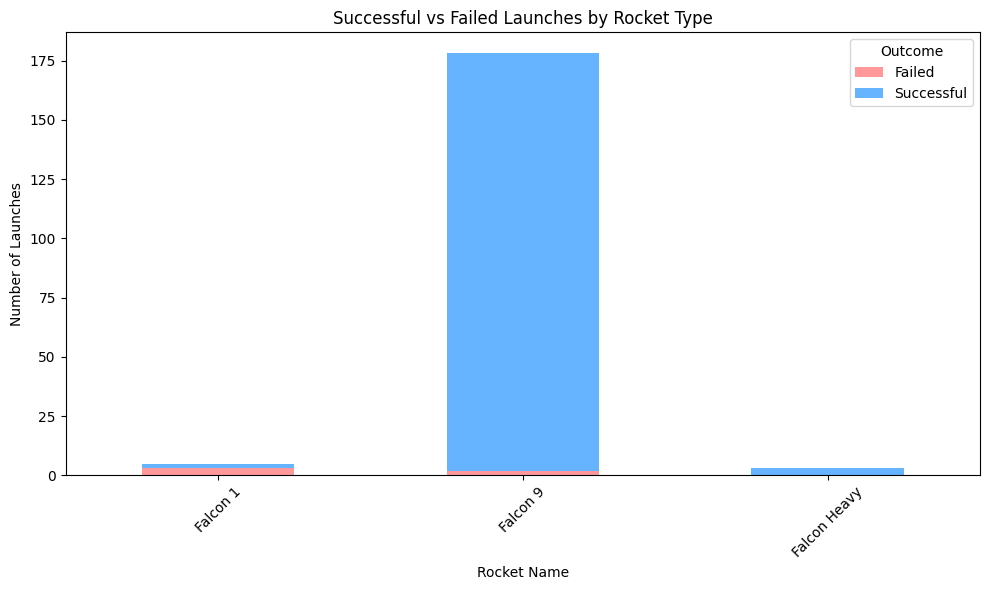

In [19]:
# --- Question 9: Stacked Bar Chart ---
# Group by rocket and success
rocket_success_counts = df_merged.groupby(['rocket_name', 'success']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
rocket_success_counts.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=plt.gca())
plt.title('Successful vs Failed Launches by Rocket Type')
plt.xlabel('Rocket Name')
plt.ylabel('Number of Launches')
# Success is boolean (False=0, True=1), map labels accordingly
plt.legend(title='Outcome', labels=['Failed', 'Successful'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


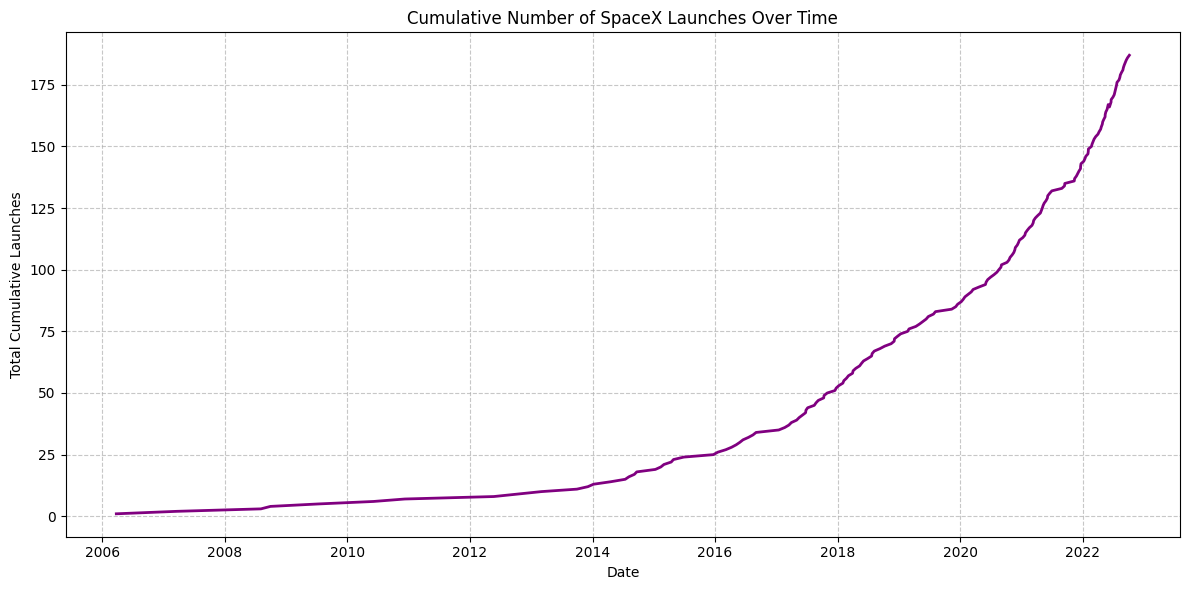

In [20]:
# --- Question 10: Cumulative Line Chart ---
# Count cumulative launches over time
df_merged['cumulative_launches'] = df_merged.reset_index().index + 1

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_merged, x='date_utc', y='cumulative_launches', color='purple', linewidth=2)
plt.title('Cumulative Number of SpaceX Launches Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cumulative Launches')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()